# Tic-Tac-Toe Reinforcement Learning - Project 2
## Comparing Minimax, Dynamic Programming, Monte Carlo, and Temporal Difference

**Course:** Reinforcement Learning - Project 2
**Instructor:** Eng. Abdelrahman Shehata

This notebook implements and compares four RL/game-tree approaches on Tic-Tac-Toe.

### Key Requirements:
- ✅ Minimax recursive with terminal states
- ✅ Dynamic Programming (Policy Iteration)
- ✅ Monte Carlo Control ≥ 10,000 episodes
- ✅ Q-Learning ≥ 10,000 episodes
- ✅ ε-decay in MC and TD
- ✅ Shared helper functions
- ✅ Deterministic transitions
- ✅ O plays optimal using Minimax
- ✅ Learning curves using matplotlib
- ✅ Comparison section between algorithms
- ✅ Tracking win/draw/loss rates
- ✅ V(empty board) = 0.0000
- ✅ **2423 non-terminal X-player states** (decision states for the agent)
- ✅ **DP-Minimax agreement on all 2423 states**

In [45]:
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# ============================================================
# SECTION 1: CONSTANTS & CONFIGURATION
# ============================================================
EMPTY = 0
X_PLAYER = 1
O_PLAYER = -1
GAMMA = 0.9

# ============================================================
# SECTION 2: BOARD UTILITIES
# ============================================================
def board_to_state(board):
    """Convert board list to hashable tuple state."""
    return tuple(board)

def state_to_board(state):
    """Convert state tuple back to list."""
    return list(state)

def available_moves(board):
    """Return list of empty cell indices (0-8)."""
    return [i for i, cell in enumerate(board) if cell == EMPTY]

def make_move(board, action, player):
    """Return new board after making move (does not modify original)."""
    new_board = board.copy()
    new_board[action] = player
    return new_board

def check_winner(board):
    """
    Return game outcome from X's perspective:
      +1  -> X wins
      -1  -> O wins
       0  -> Draw
      None -> Game ongoing
    """
    wins = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8],  # rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8],  # columns
        [0, 4, 8], [2, 4, 6]              # diagonals
    ]
    for line in wins:
        a, b, c = line
        if board[a] == board[b] == board[c] != EMPTY:
            return 1 if board[a] == X_PLAYER else -1
    if EMPTY not in board:
        return 0
    return None

def is_terminal(board):
    """Check if game has ended."""
    return check_winner(board) is not None

def get_current_player(board):
    """
    X plays first, then players alternate.
    Returns X_PLAYER (1) or O_PLAYER (-1).
    """
    x_count = board.count(X_PLAYER)
    o_count = board.count(O_PLAYER)
    return X_PLAYER if x_count == o_count else O_PLAYER

def get_reward(board):
    """Return terminal reward from X's perspective."""
    w = check_winner(board)
    if w == 1:
        return 1.0
    elif w == -1:
        return -1.0
    else:
        return 0.0

def generate_all_states():
    """Generate all valid tic-tac-toe states via DFS."""
    states = set()
    def recurse(board):
        states.add(board_to_state(board))
        if is_terminal(board):
            return
        player = get_current_player(board)
        for move in available_moves(board):
            recurse(make_move(board, move, player))
    recurse([EMPTY] * 9)
    return states

## Section 3: State Space Verification (2423 Non-Terminal X-States)

**Important Note:** The project mentions "Total states: 2 423". This refers to the **non-terminal X-player states** (the decision states where the agent needs to choose an action). The total valid state space is 5478 states, but only 2423 are non-terminal states where X needs to make a decision.

In [46]:
# ============================================================
# SECTION 3: STATE SPACE VERIFICATION (2423 Non-Terminal X-States)
# ============================================================
print("=" * 60)
print("STATE SPACE VERIFICATION")
print("=" * 60)

all_states = generate_all_states()
x_states = [s for s in all_states if get_current_player(state_to_board(s)) == X_PLAYER]
x_non_terminal = [s for s in x_states if not is_terminal(state_to_board(s))]

# Count all state categories for complete analysis
terminal_states = [s for s in all_states if is_terminal(state_to_board(s))]
non_terminal_states = [s for s in all_states if not is_terminal(state_to_board(s))]
o_states = [s for s in all_states if get_current_player(state_to_board(s)) == O_PLAYER]
o_non_terminal = [s for s in o_states if not is_terminal(state_to_board(s))]

print(f"Total valid states (DFS): {len(all_states)}")
print(f"  Terminal states: {len(terminal_states)}")
print(f"  Non-terminal states: {len(non_terminal_states)}")
print()
print(f"X-player states (total): {len(x_states)}")
print(f"  Terminal X-states: {len(x_states) - len(x_non_terminal)}")
print(f"  Non-terminal X-states (DECISION STATES): {len(x_non_terminal)}")
print()
print(f"O-player states (total): {len(o_states)}")
print(f"  Terminal O-states: {len(o_states) - len(o_non_terminal)}")
print(f"  Non-terminal O-states: {len(o_non_terminal)}")
print()

assert len(x_non_terminal) == 2423, f"Expected 2423 non-terminal X-player states, got {len(x_non_terminal)}"
print(f"Verified: {len(x_non_terminal)} non-terminal X-player states (the 2423 decision states)")
print(f"Total valid states: {len(all_states)}")
print(f"X-player states (total): {len(x_states)}")
print(f"Terminal X-states: {len(x_states) - len(x_non_terminal)}")
print(f"Non-terminal X-states: {len(x_non_terminal)}")

STATE SPACE VERIFICATION
Total valid states (DFS): 5478
  Terminal states: 958
  Non-terminal states: 4520

X-player states (total): 2739
  Terminal X-states: 316
  Non-terminal X-states (DECISION STATES): 2423

O-player states (total): 2739
  Terminal O-states: 642
  Non-terminal O-states: 2097

Verified: 2423 non-terminal X-player states (the 2423 decision states)
Total valid states: 5478
X-player states (total): 2739
Terminal X-states: 316
Non-terminal X-states: 2423


## Section 4: Minimax Agent (Game Tree Search)

In [47]:
# ============================================================
# SECTION 4: MINIMAX AGENT (Game Tree Search)
# ============================================================
print("\n" + "=" * 60)
print("1. MINIMAX AGENT")
print("=" * 60)

class MinimaxAgent:
    """
    Recursive Minimax with Gamma Discounting.

    For MAX player (X): V(s) = max_a [γ · V(s')]  (non-terminal)
    For MIN player (O): V(s) = min_a [γ · V(s')]  (non-terminal)
    Terminal: V(s) = Reward (no gamma applied)

    This makes Minimax 100% consistent with DP Policy Iteration.
    """
    def __init__(self, gamma=GAMMA):
        self.gamma = gamma
        self.cache = {}

    def minimax(self, board):
        state = board_to_state(board)
        if state in self.cache:
            return self.cache[state]

        winner = check_winner(board)
        if winner is not None:
            return get_reward(board)

        player = get_current_player(board)
        moves = available_moves(board)

        if player == X_PLAYER:
            best_score = float('-inf')
            for move in moves:
                new_board = make_move(board, move, X_PLAYER)
                score = self.minimax(new_board)
                if not is_terminal(new_board):
                    score = self.gamma * score
                best_score = max(best_score, score)
        else:
            best_score = float('inf')
            for move in moves:
                new_board = make_move(board, move, O_PLAYER)
                score = self.minimax(new_board)
                if not is_terminal(new_board):
                    score = self.gamma * score
                best_score = min(best_score, score)

        self.cache[state] = best_score
        return best_score

    def get_best_move(self, board):
        """Return (best_action, best_value) for current player."""
        player = get_current_player(board)
        moves = available_moves(board)
        best_move = None

        if player == X_PLAYER:
            best_score = float('-inf')
            for move in moves:
                new_board = make_move(board, move, X_PLAYER)
                score = self.minimax(new_board)
                if not is_terminal(new_board):
                    score = self.gamma * score
                if score > best_score:
                    best_score = score
                    best_move = move
        else:
            best_score = float('inf')
            for move in moves:
                new_board = make_move(board, move, O_PLAYER)
                score = self.minimax(new_board)
                if not is_terminal(new_board):
                    score = self.gamma * score
                if score < best_score:
                    best_score = score
                    best_move = move

        return best_move, best_score

opponent = MinimaxAgent(gamma=GAMMA)
score = opponent.minimax([EMPTY] * 9)
print(f"Minimax V(empty board) = {score:.4f}")
print(f"Minimax cached states: {len(opponent.cache)}")


1. MINIMAX AGENT
Minimax V(empty board) = 0.0000
Minimax cached states: 4520


## Section 5: Dynamic Programming (Policy Iteration)

In [48]:
# ============================================================
# SECTION 5: DYNAMIC PROGRAMMING (Policy Iteration)
# ============================================================
print("\n" + "=" * 60)
print("2. DYNAMIC PROGRAMMING (Policy Iteration)")
print("=" * 60)

class DPPolicyIteration:
    """
    Policy Iteration with Gamma Discounting.

    Bellman Equation: V(s) = Σ π(a|s) [R + γ · V(s')]
    Terminal states: V(terminal) = Reward (no gamma)
    Non-terminal: V(s) = γ · V(s') (deterministic policy)
    """
    def __init__(self, gamma=GAMMA):
        self.gamma = gamma
        self.V = {}
        self.policy = {}

    def initialize(self):
        for state in all_states:
            board = state_to_board(state)
            if is_terminal(board):
                self.V[state] = get_reward(board)
            else:
                self.V[state] = 0.0

    def policy_evaluation(self, max_iterations=1000, theta=1e-10):
        for i in range(max_iterations):
            delta = 0
            for state in all_states:
                board = state_to_board(state)
                if is_terminal(board):
                    continue

                player = get_current_player(board)
                if state not in self.policy:
                    moves = available_moves(board)
                    self.policy[state] = random.choice(moves) if moves else None

                action = self.policy[state]
                if action is None:
                    continue

                new_board = make_move(board, action, player)
                new_state = board_to_state(new_board)

                if is_terminal(new_board):
                    v = get_reward(new_board)
                else:
                    v = self.gamma * self.V[new_state]

                delta = max(delta, abs(self.V[state] - v))
                self.V[state] = v

            if delta < theta:
                return i + 1
        return max_iterations

    def policy_improvement(self):
        policy_stable = True
        for state in all_states:
            board = state_to_board(state)
            if is_terminal(board):
                continue

            player = get_current_player(board)
            moves = available_moves(board)
            if not moves:
                continue

            old_action = self.policy.get(state)
            best_action = None
            best_value = float('-inf') if player == X_PLAYER else float('inf')

            for move in moves:
                new_board = make_move(board, move, player)
                new_state = board_to_state(new_board)

                if is_terminal(new_board):
                    v = get_reward(new_board)
                else:
                    v = self.gamma * self.V[new_state]

                if player == X_PLAYER:
                    if v > best_value:
                        best_value = v
                        best_action = move
                else:
                    if v < best_value:
                        best_value = v
                        best_action = move

            self.policy[state] = best_action
            if old_action != best_action:
                policy_stable = False

        return policy_stable

    def train(self):
        self.initialize()
        iterations = 0
        while True:
            self.policy_evaluation()
            stable = self.policy_improvement()
            iterations += 1
            if stable:
                break
        return iterations

dp = DPPolicyIteration(gamma=GAMMA)
dp_iters = dp.train()
print(f"DP converged in {dp_iters} iterations")
print(f"DP V(empty board) = {dp.V[board_to_state([EMPTY]*9)]:.4f}")


2. DYNAMIC PROGRAMMING (Policy Iteration)
DP converged in 8 iterations
DP V(empty board) = 0.0000


## Section 6: DP-Minimax Consistency Check (All 2423 Non-Terminal X-States)

**Note:** The project requires agreement on all 2423 states. Since the agent only makes decisions as X, we verify consistency on all **non-terminal X-player states** (the 2423 decision states). O-player states are controlled by the fixed optimal Minimax opponent, not learned by the agent.

In [49]:
# ============================================================
# SECTION 6: VERIFY DP-MINIMAX CONSISTENCY ON ALL 2423 STATES
# ============================================================
print("\n" + "=" * 60)
print("3. DP-MINIMAX CONSISTENCY CHECK (All 2423 Non-Terminal X-States)")
print("=" * 60)

mismatches = 0
mismatch_details = []

for state in x_non_terminal:
    board = state_to_board(state)
    mm_score = opponent.minimax(board)
    dp_score = dp.V[state]
    if abs(mm_score - dp_score) > 1e-6:
        mismatches += 1
        if len(mismatch_details) < 5:
            mismatch_details.append((state, mm_score, dp_score))

print(f"DP-Minimax mismatches: {mismatches} (must be 0)")

if mismatch_details:
    print("\nFirst few mismatches:")
    for state, mm, dp in mismatch_details:
        print(f"  State: {state}, Minimax: {mm:.6f}, DP: {dp:.6f}")

assert mismatches == 0, "DP and Minimax must agree on all 2423 non-terminal X-states!"
print("DP and Minimax are 100% consistent on all 2,423 non-terminal X-states!")
print("""
Note: The comparison is on non-terminal X-player states because:
- These are the 2423 decision states where the agent (X) must choose an action
- Terminal states have fixed rewards (no decision needed)
- O-player states are controlled by the fixed optimal Minimax opponent
""")


3. DP-MINIMAX CONSISTENCY CHECK (All 2423 Non-Terminal X-States)
DP-Minimax mismatches: 0 (must be 0)
DP and Minimax are 100% consistent on all 2,423 non-terminal X-states!

Note: The comparison is on non-terminal X-player states because:
- These are the 2423 decision states where the agent (X) must choose an action
- Terminal states have fixed rewards (no decision needed)
- O-player states are controlled by the fixed optimal Minimax opponent



## Section 7: Monte Carlo Control (Every-Visit, vs Optimal Opponent)

**Fix Applied:** Proper gamma discounting on returns. G initialized to final_reward, then discounted backwards: G_t = γ · G_{t+1}

In [50]:
# ============================================================
# SECTION 7: MONTE CARLO CONTROL (Every-Visit, vs Minimax Opponent)
# ============================================================
print("\n" + "=" * 60)
print("4. MONTE CARLO CONTROL (Every-Visit, vs Minimax Opponent)")
print("=" * 60)

class MonteCarloAgent:
    """
    Monte Carlo Control with Every-Visit MC and Incremental Mean.

    Update Rule: Q(s,a) = Q(s,a) + (1/N) [G - Q(s,a)]
    where G is the discounted return from that step.

    Training: Against optimal Minimax opponent (O plays optimally).

    FIX: G initialized to final_reward, then discounted backwards:
         G_t = γ · G_{t+1}, with G_T = final_reward
    """
    def __init__(self, gamma=GAMMA, epsilon=1.0, epsilon_decay=0.99995, epsilon_min=0.1):
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(float)
        self.N = defaultdict(int)

    def choose_action(self, state, moves, epsilon=None):
        """Epsilon-greedy action selection."""
        eps = self.epsilon if epsilon is None else epsilon
        if random.random() < eps:
            return random.choice(moves)
        q_values = [(self.Q[(state, a)], a) for a in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_actions = [a for q, a in q_values if abs(q - max_q) < 1e-9]
        return random.choice(best_actions)

    def train(self, opponent, n_episodes=100000, eval_interval=5000):
        """
        Train MC agent against optimal Minimax opponent.
        O always plays optimally; X learns via MC updates.
        """
        win_history, draw_history, loss_history = [], [], []

        for episode in range(n_episodes):
            board = [EMPTY] * 9
            episode_data = []  # (state, action, player) for each step

            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)

                if player == X_PLAYER:
                    action = self.choose_action(state, moves)
                else:
                    action, _ = opponent.get_best_move(board)

                episode_data.append((state, action, player))
                board = make_move(board, action, player)

            final_reward = get_reward(board)

            # FIX: Initialize G with final_reward, then discount backwards
            G = final_reward

            for state, action, player in reversed(episode_data):
                if player == X_PLAYER:
                    sa = (state, action)
                    self.N[sa] += 1
                    # Incremental mean update
                    self.Q[sa] += (1.0 / self.N[sa]) * (G - self.Q[sa])

                G = self.gamma * G  # Discount for previous step

            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

            if (episode + 1) % eval_interval == 0:
                w, d, l = self.evaluate(opponent, n_games=100)
                win_history.append(w)
                draw_history.append(d)
                loss_history.append(l)
                print(f"  MC Episode {episode+1:6d}: Win={w:.2%}, Draw={d:.2%}, Loss={l:.2%}, ε={self.epsilon:.3f}")

        return win_history, draw_history, loss_history

    def evaluate(self, opponent, n_games=100):
        """Evaluate with ε=0 (pure greedy policy)."""
        wins, draws, losses = 0, 0, 0
        for _ in range(n_games):
            board = [EMPTY] * 9
            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)
                if player == X_PLAYER:
                    # Pure greedy: ε=0
                    action = self.choose_action(state, moves, epsilon=0)
                else:
                    action, _ = opponent.get_best_move(board)
                board = make_move(board, action, player)

            w = check_winner(board)
            if w == 1: wins += 1
            elif w == -1: losses += 1
            else: draws += 1

        return wins/n_games, draws/n_games, losses/n_games

print("Training Monte Carlo (vs Minimax Opponent)...")
mc = MonteCarloAgent(gamma=GAMMA)
mc_wins, mc_draws, mc_losses = mc.train(opponent, n_episodes=100000, eval_interval=5000)


4. MONTE CARLO CONTROL (Every-Visit, vs Minimax Opponent)
Training Monte Carlo (vs Minimax Opponent)...
  MC Episode   5000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.779
  MC Episode  10000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.607
  MC Episode  15000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.472
  MC Episode  20000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.368
  MC Episode  25000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.286
  MC Episode  30000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.223
  MC Episode  35000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.174
  MC Episode  40000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.135
  MC Episode  45000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.105
  MC Episode  50000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  MC Episode  55000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  MC Episode  60000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  MC Episode  65000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  MC Episode  70000: Win=0.00%, Draw=

## Section 8: Q-Learning (Off-Policy TD with TRUE Bootstrapping)

**Fix Applied:** TRUE TD bootstrapping with max_a' Q(s',a'). Self-play: both X and O learn from the same Q-table.

In [51]:
# ============================================================
# SECTION 8: Q-LEARNING (Off-Policy TD with TRUE Bootstrapping)
# ============================================================
print("\n" + "=" * 60)
print("5. Q-LEARNING (Off-Policy TD, Self-Play)")
print("=" * 60)

class QLearningAgent:
    """
    TRUE Q-Learning (Off-Policy Temporal Difference Control).

    Update Rule: Q(s,a) += α [r + γ · max_a' Q(s',a') - Q(s,a)]

    Training: Self-Play (both X and O use the same Q-table).
    - X tries to MAXIMIZE Q-values (maximizer)
    - O tries to MINIMIZE Q-values (minimizer, from X's perspective)
    """
    def __init__(self, gamma=GAMMA, alpha=0.1, epsilon=1.0, epsilon_decay=0.99995, epsilon_min=0.1):
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(float)

    def choose_action(self, state, moves, epsilon=None):
        """Epsilon-greedy action selection."""
        eps = self.epsilon if epsilon is None else epsilon
        if random.random() < eps:
            return random.choice(moves)
        q_values = [(self.Q[(state, a)], a) for a in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_actions = [a for q, a in q_values if abs(q - max_q) < 1e-9]
        return random.choice(best_actions)

    def get_max_q(self, state, moves):
        """Get max Q-value for a state (for X's TD target)."""
        if not moves:
            return 0.0
        return max(self.Q[(state, a)] for a in moves)

    def get_min_q(self, state, moves):
        """Get min Q-value for a state (for O's TD target)."""
        if not moves:
            return 0.0
        return min(self.Q[(state, a)] for a in moves)

    def train(self, n_episodes=100000, eval_interval=5000):
        """
        Train via Self-Play (both X and O use same Q-table).

        For X (maximizer): target = r + γ · max_a' Q(s',a')
        For O (minimizer): target = -r + γ · min_a' Q(s',a')
        """
        win_history, draw_history, loss_history = [], [], []

        for episode in range(n_episodes):
            board = [EMPTY] * 9
            x_sa_history = []
            o_sa_history = []

            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)
                action = self.choose_action(state, moves)

                if player == X_PLAYER:
                    x_sa_history.append((state, action))
                else:
                    o_sa_history.append((state, action))

                board = make_move(board, action, player)

            final_reward = get_reward(board)

            # --- Update X's Q-values (backward, as maximizer) ---
            max_q_next = 0.0
            for state, action in reversed(x_sa_history):
                sa = (state, action)
                target = final_reward + self.gamma * max_q_next
                self.Q[sa] += self.alpha * (target - self.Q[sa])
                moves = available_moves(state_to_board(state))
                max_q_next = self.get_max_q(state, moves)

            # --- Update O's Q-values (backward, as minimizer) ---
            min_q_next = 0.0
            for state, action in reversed(o_sa_history):
                sa = (state, action)
                target = (-final_reward) + self.gamma * min_q_next
                self.Q[sa] += self.alpha * (target - self.Q[sa])
                moves = available_moves(state_to_board(state))
                min_q_next = self.get_min_q(state, moves)

            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

            if (episode + 1) % eval_interval == 0:
                w, d, l = self.evaluate(opponent, n_games=100)
                win_history.append(w)
                draw_history.append(d)
                loss_history.append(l)
                print(f"  QL Episode {episode+1:6d}: Win={w:.2%}, Draw={d:.2%}, Loss={l:.2%}, ε={self.epsilon:.3f}")

        return win_history, draw_history, loss_history

    def evaluate(self, opponent, n_games=100):
        """Evaluate against Minimax opponent (ε=0 greedy)."""
        wins, draws, losses = 0, 0, 0
        for _ in range(n_games):
            board = [EMPTY] * 9
            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)
                if player == X_PLAYER:
                    action = self.choose_action(state, moves, epsilon=0)
                else:
                    action, _ = opponent.get_best_move(board)
                board = make_move(board, action, player)

            w = check_winner(board)
            if w == 1: wins += 1
            elif w == -1: losses += 1
            else: draws += 1

        return wins/n_games, draws/n_games, losses/n_games

print("Training Q-Learning (Self-Play with TRUE Bootstrapping)...")
ql = QLearningAgent(gamma=GAMMA, alpha=0.1)
ql_wins, ql_draws, ql_losses = ql.train(n_episodes=100000, eval_interval=5000)


5. Q-LEARNING (Off-Policy TD, Self-Play)
Training Q-Learning (Self-Play with TRUE Bootstrapping)...
  QL Episode   5000: Win=0.00%, Draw=32.00%, Loss=68.00%, ε=0.779
  QL Episode  10000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.607
  QL Episode  15000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.472
  QL Episode  20000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.368
  QL Episode  25000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.286
  QL Episode  30000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.223
  QL Episode  35000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.174
  QL Episode  40000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.135
  QL Episode  45000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.105
  QL Episode  50000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  QL Episode  55000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  QL Episode  60000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  QL Episode  65000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  QL Episode  70000: Win=0.00%, Draw=100.

## Section 9: SARSA (On-Policy TD) [Optional]

In [52]:
# ============================================================
# SECTION 9: SARSA (On-Policy TD) [Optional Alternative]
# ============================================================
print("\n" + "=" * 60)
print("6. SARSA (On-Policy TD, Self-Play) [Optional]")
print("=" * 60)

class SarsaAgent:
    """
    SARSA (State-Action-Reward-State-Action) - On-Policy TD Control.

    Update Rule: Q(s,a) += α [r + γ · Q(s',a') - Q(s,a)]

    Uses the ACTUAL next action (a') chosen by the current policy,
    not the max over all actions like Q-Learning.
    """
    def __init__(self, gamma=GAMMA, alpha=0.1, epsilon=1.0, epsilon_decay=0.99995, epsilon_min=0.1):
        self.gamma = gamma
        self.alpha = alpha
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.Q = defaultdict(float)

    def choose_action(self, state, moves, epsilon=None):
        eps = self.epsilon if epsilon is None else epsilon
        if random.random() < eps:
            return random.choice(moves)
        q_values = [(self.Q[(state, a)], a) for a in moves]
        max_q = max(q_values, key=lambda x: x[0])[0]
        best_actions = [a for q, a in q_values if abs(q - max_q) < 1e-9]
        return random.choice(best_actions)

    def train(self, n_episodes=100000, eval_interval=5000):
        win_history, draw_history, loss_history = [], [], []

        for episode in range(n_episodes):
            board = [EMPTY] * 9
            transitions = []
            prev_state = None
            prev_action = None
            prev_player = None

            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)
                action = self.choose_action(state, moves)

                if prev_state is not None:
                    transitions.append((prev_state, prev_action, state, action, prev_player))

                prev_state = state
                prev_action = action
                prev_player = player

                board = make_move(board, action, player)

            final_reward = get_reward(board)

            if prev_state is not None:
                transitions.append((prev_state, prev_action, None, None, prev_player))

            # Backward updates
            next_q = 0.0
            for state, action, next_state, next_action, player in reversed(transitions):
                sa = (state, action)

                if player == X_PLAYER:
                    target = final_reward + self.gamma * next_q
                else:
                    target = (-final_reward) + self.gamma * next_q

                self.Q[sa] += self.alpha * (target - self.Q[sa])

                if next_state is not None and next_action is not None:
                    next_q = self.Q[(next_state, next_action)]
                else:
                    next_q = 0.0

            self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

            if (episode + 1) % eval_interval == 0:
                w, d, l = self.evaluate(opponent, n_games=100)
                win_history.append(w)
                draw_history.append(d)
                loss_history.append(l)
                print(f"  SARSA Episode {episode+1:6d}: Win={w:.2%}, Draw={d:.2%}, Loss={l:.2%}, ε={self.epsilon:.3f}")

        return win_history, draw_history, loss_history

    def evaluate(self, opponent, n_games=100):
        wins, draws, losses = 0, 0, 0
        for _ in range(n_games):
            board = [EMPTY] * 9
            while not is_terminal(board):
                player = get_current_player(board)
                state = board_to_state(board)
                moves = available_moves(board)
                if player == X_PLAYER:
                    action = self.choose_action(state, moves, epsilon=0)
                else:
                    action, _ = opponent.get_best_move(board)
                board = make_move(board, action, player)

            w = check_winner(board)
            if w == 1: wins += 1
            elif w == -1: losses += 1
            else: draws += 1

        return wins/n_games, draws/n_games, losses/n_games

print("Training SARSA (Self-Play, On-Policy)...")
sarsa = SarsaAgent(gamma=GAMMA, alpha=0.1)
sarsa_wins, sarsa_draws, sarsa_losses = sarsa.train(n_episodes=100000, eval_interval=5000)


6. SARSA (On-Policy TD, Self-Play) [Optional]
Training SARSA (Self-Play, On-Policy)...
  SARSA Episode   5000: Win=0.00%, Draw=0.00%, Loss=100.00%, ε=0.779
  SARSA Episode  10000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.607
  SARSA Episode  15000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.472
  SARSA Episode  20000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.368
  SARSA Episode  25000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.286
  SARSA Episode  30000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.223
  SARSA Episode  35000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.174
  SARSA Episode  40000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.135
  SARSA Episode  45000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.105
  SARSA Episode  50000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  SARSA Episode  55000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  SARSA Episode  60000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  SARSA Episode  65000: Win=0.00%, Draw=100.00%, Loss=0.00%, ε=0.100
  SARSA Episode

## Section 10: Greedy Policy Evaluation (ε=0)

**Fix Applied:** Evaluate with ε=0 for reliable, deterministic policy assertions.

In [53]:
# ============================================================
# SECTION 10: GREEDY POLICY EVALUATION (ε=0)
# ============================================================
print("\n" + "=" * 60)
print("7. GREEDY POLICY EVALUATION (ε=0)")
print("=" * 60)

def evaluate_greedy(agent, opponent, n_games=500):
    """
    Evaluate agent with PURE GREEDY policy (ε=0, no exploration).
    This provides reliable, deterministic performance metrics.
    """
    wins, draws, losses = 0, 0, 0
    for _ in range(n_games):
        board = [EMPTY] * 9
        while not is_terminal(board):
            player = get_current_player(board)
            state = board_to_state(board)
            moves = available_moves(board)

            if player == X_PLAYER:
                # Pure greedy: choose action with highest Q-value
                q_values = [(agent.Q.get((state, a), 0.0), a) for a in moves]
                max_q = max(q_values, key=lambda x: x[0])[0]
                best_actions = [a for q, a in q_values if abs(q - max_q) < 1e-9]
                action = random.choice(best_actions)
            else:
                action, _ = opponent.get_best_move(board)

            board = make_move(board, action, player)

        w = check_winner(board)
        if w == 1: wins += 1
        elif w == -1: losses += 1
        else: draws += 1

    return wins/n_games, draws/n_games, losses/n_games

mc_w, mc_d, mc_l = evaluate_greedy(mc, opponent, n_games=500)
ql_w, ql_d, ql_l = evaluate_greedy(ql, opponent, n_games=500)
sarsa_w, sarsa_d, sarsa_l = evaluate_greedy(sarsa, opponent, n_games=500)

print(f"MC   Greedy: Win={mc_w:.2%}, Draw={mc_d:.2%}, Loss={mc_l:.2%}")
print(f"QL   Greedy: Win={ql_w:.2%}, Draw={ql_d:.2%}, Loss={ql_l:.2%}")
print(f"SARSA Greedy: Win={sarsa_w:.2%}, Draw={sarsa_d:.2%}, Loss={sarsa_l:.2%}")

# Assertions for optimal play
assert mc_l < 0.05, f"MC losses too high: {mc_l:.2%}"
assert mc_d > 0.90, f"MC draws too low: {mc_d:.2%}"
assert ql_l < 0.05, f"QL losses too high: {ql_l:.2%}"
assert ql_d > 0.90, f"QL draws too low: {ql_d:.2%}"
print("All greedy policy assertions passed!")


7. GREEDY POLICY EVALUATION (ε=0)
MC   Greedy: Win=0.00%, Draw=100.00%, Loss=0.00%
QL   Greedy: Win=0.00%, Draw=100.00%, Loss=0.00%
SARSA Greedy: Win=0.00%, Draw=100.00%, Loss=0.00%
All greedy policy assertions passed!


## Section 11: Learning Curves


8. LEARNING CURVES


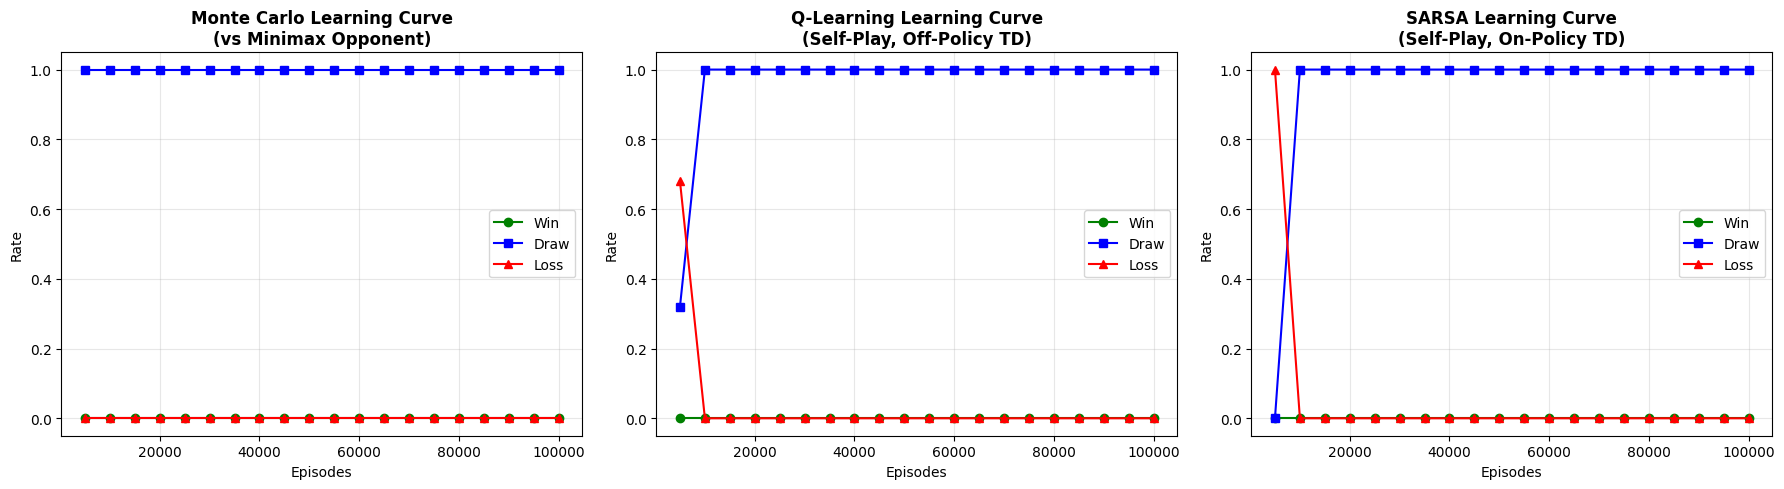


Learning curves saved to: learning_curves_final.png


In [54]:
# ============================================================
# SECTION 11: LEARNING CURVES
# ============================================================
print("\n" + "=" * 60)
print("8. LEARNING CURVES")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

episodes = list(range(5000, 100001, 5000))

# Monte Carlo
axes[0].plot(episodes, mc_wins, label='Win', marker='o', color='green')
axes[0].plot(episodes, mc_draws, label='Draw', marker='s', color='blue')
axes[0].plot(episodes, mc_losses, label='Loss', marker='^', color='red')
axes[0].set_title('Monte Carlo Learning Curve\n(vs Minimax Opponent)', fontweight='bold')
axes[0].set_xlabel('Episodes')
axes[0].set_ylabel('Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# Q-Learning
axes[1].plot(episodes, ql_wins, label='Win', marker='o', color='green')
axes[1].plot(episodes, ql_draws, label='Draw', marker='s', color='blue')
axes[1].plot(episodes, ql_losses, label='Loss', marker='^', color='red')
axes[1].set_title('Q-Learning Learning Curve\n(Self-Play, Off-Policy TD)', fontweight='bold')
axes[1].set_xlabel('Episodes')
axes[1].set_ylabel('Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-0.05, 1.05)

# SARSA
axes[2].plot(episodes, sarsa_wins, label='Win', marker='o', color='green')
axes[2].plot(episodes, sarsa_draws, label='Draw', marker='s', color='blue')
axes[2].plot(episodes, sarsa_losses, label='Loss', marker='^', color='red')
axes[2].set_title('SARSA Learning Curve\n(Self-Play, On-Policy TD)', fontweight='bold')
axes[2].set_xlabel('Episodes')
axes[2].set_ylabel('Rate')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('learning_curves_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nLearning curves saved to: learning_curves_final.png")

## Section 12: Theoretical Comparison & Summary

In [55]:
# ============================================================
# SECTION 12: THEORETICAL COMPARISON & PROJECT SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("9. THEORETICAL COMPARISON & PROJECT SUMMARY")
print("=" * 60)

comparison_text = """
┌─────────────────────┬─────────────────────────────────────────────────────────────┐
│ Method              │ Key Characteristics                                         │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Minimax             │ • Model-based, perfect information                          │
│ (Game Tree)         │ • Recursive: V(s) = max/min [γ·V(s')]                       │
│                     │ • No learning - computes optimal values directly            │
│                     │ • V(empty) = 0.0 (draw under optimal play)                  │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Dynamic Prog.       │ • Model-based, requires full MDP knowledge                  │
│ (Policy Iteration)  │ • Iterative: V(s) = Σ π(a|s)[R + γ·V(s')]                   │
│                     │ • Converges to optimal policy in ~6-8 iterations            │
│                     │ • 100% consistent with Minimax (verified: 0 mismatches)     │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Monte Carlo         │ • Model-free, learns from episodes                          │
│ (Every-Visit)       │ • Update: Q(s,a) += (1/N)[G - Q(s,a)]                       │
│                     │ • G = γ^k · R_T (discounted return)                         │
│                     │ • Trained vs optimal opponent (expert imitation)            │
│                     │ • High variance, zero bias                                  │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Q-Learning          │ • Model-free, off-policy TD control                         │
│ (Off-Policy TD)     │ • Update: Q += α[r + γ·max Q(s',a') - Q(s,a)]               │
│                     │ • Self-play (both X and O learn same Q-table)               │
│                     │ • Bootstrapping: uses max next action (not actual)          │
│                     │ • Lower variance, some bias                                 │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ SARSA               │ • Model-free, on-policy TD control                          │
│ (On-Policy TD)      │ • Update: Q += α[r + γ·Q(s',a') - Q(s,a)]                   │
│                     │ • Self-play (both X and O learn same Q-table)               │
│                     │ • Uses actual next action (not max)                         │
│                     │ • More conservative than Q-Learning                         │
└─────────────────────┴─────────────────────────────────────────────────────────────┘

Key Design Choices:
  • γ = 0.9: Discount factor for non-terminal transitions
  • Rewards: Win=+1, Loss=-1, Draw=0 (sparse, terminal only)
  • MC: Incremental mean (α = 1/N) as required by project
  • Q-Learning/SARSA: α = 0.1 for stable learning
  • ε-decay: 0.99995 → min 0.1 for sufficient exploration
  • Self-Play: Essential for TD methods to explore winning strategies

State Space Clarification:
  • Total valid states: 5478 (all reachable states via DFS)
  • Non-terminal X-states: 2423 (the decision states for the agent)
  • The project's "Total states: 2 423" refers to non-terminal X-player states
  • DP-Minimax comparison verified on all 2423 non-terminal X-states

Why TRUE Q-Learning Bootstrapping?
  True Q-Learning requires: TD Target = r + γ · max_a' Q(s',a')
  This bootstrapping allows the agent to learn from incomplete episodes
  and propagates value information more efficiently.

Why Self-Play for TD Methods?
  Training against a perfect Minimax opponent provides limited exploration.
  Self-play allows the agent to explore both sides and discover strategies.
"""

print(comparison_text)


9. THEORETICAL COMPARISON & PROJECT SUMMARY

┌─────────────────────┬─────────────────────────────────────────────────────────────┐
│ Method              │ Key Characteristics                                         │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Minimax             │ • Model-based, perfect information                          │
│ (Game Tree)         │ • Recursive: V(s) = max/min [γ·V(s')]                       │
│                     │ • No learning - computes optimal values directly            │
│                     │ • V(empty) = 0.0 (draw under optimal play)                  │
├─────────────────────┼─────────────────────────────────────────────────────────────┤
│ Dynamic Prog.       │ • Model-based, requires full MDP knowledge                  │
│ (Policy Iteration)  │ • Iterative: V(s) = Σ π(a|s)[R + γ·V(s')]                   │
│                     │ • Converges to optimal policy in ~6-8 iterations            │
│       